Objetivo: Implementar una Red Neuronal Recurrente (LSTM) para predecir variables
climáticas futuras basándose en datos históricos de temperatura, humedad, 
velocidad del viento y presión atmosférica.

Las RNN son ideales para este problema porque:
1. Los datos climáticos son secuencias temporales con dependencias
2. El clima de hoy depende del clima de días anteriores
3. Existen patrones estacionales y tendencias a largo plazo

Predicción: Temperatura media del día siguiente

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU disponible:", "Sí" if tf.config.list_physical_devices('GPU') else "No")
df_train = pd.read_csv('DailyDelhiClimateTrain.csv')
df_test = pd.read_csv('DailyDelhiClimateTest.csv')
df = df_train.copy()

TensorFlow version: 2.20.0
GPU disponible: No


In [2]:

print("=" * 80)
print("ANÁLISIS EXPLORATORIO DEL DATASET")
print("=" * 80)


print(f"\n1. DIMENSIONES DEL DATASET:")
print(f"   - Número de registros: {df.shape[0]:,}")
print(f"   - Número de columnas: {df.shape[1]}")
print(f"   - Período: {df.shape[0]} días")

print(f"\n2. COLUMNAS Y TIPOS DE DATOS:")
print(df.dtypes)

print(f"\n3. PRIMERAS FILAS:")
print(df.head(10))

print(f"\n4. ESTADÍSTICAS DESCRIPTIVAS:")
print(df.describe())

print(f"\n5. VALORES NULOS:")
print(df.isnull().sum())

print(f"\n6. INFORMACIÓN DEL DATASET:")
print(df.info())

ANÁLISIS EXPLORATORIO DEL DATASET

1. DIMENSIONES DEL DATASET:
   - Número de registros: 1,462
   - Número de columnas: 5
   - Período: 1462 días

2. COLUMNAS Y TIPOS DE DATOS:
date             object
meantemp        float64
humidity        float64
wind_speed      float64
meanpressure    float64
dtype: object

3. PRIMERAS FILAS:
         date   meantemp   humidity  wind_speed  meanpressure
0  2013-01-01  10.000000  84.500000    0.000000   1015.666667
1  2013-01-02   7.400000  92.000000    2.980000   1017.800000
2  2013-01-03   7.166667  87.000000    4.633333   1018.666667
3  2013-01-04   8.666667  71.333333    1.233333   1017.166667
4  2013-01-05   6.000000  86.833333    3.700000   1016.500000
5  2013-01-06   7.000000  82.800000    1.480000   1018.000000
6  2013-01-07   7.000000  78.600000    6.300000   1020.000000
7  2013-01-08   8.857143  63.714286    7.142857   1018.714286
8  2013-01-09  14.000000  51.250000   12.500000   1017.000000
9  2013-01-10  11.000000  62.000000    7.400000  


LIMPIEZA Y PREPROCESAMIENTO

1. Rango de fechas:
   - Inicio: 2013-01-01 00:00:00
   - Fin: 2017-01-01 00:00:00
   - Días totales: 1461

2. Verificación de calidad de datos:
   - Valores nulos: 0
   - Valores duplicados: 0

3. Dataset limpio: 1462 registros

ANÁLISIS VISUAL


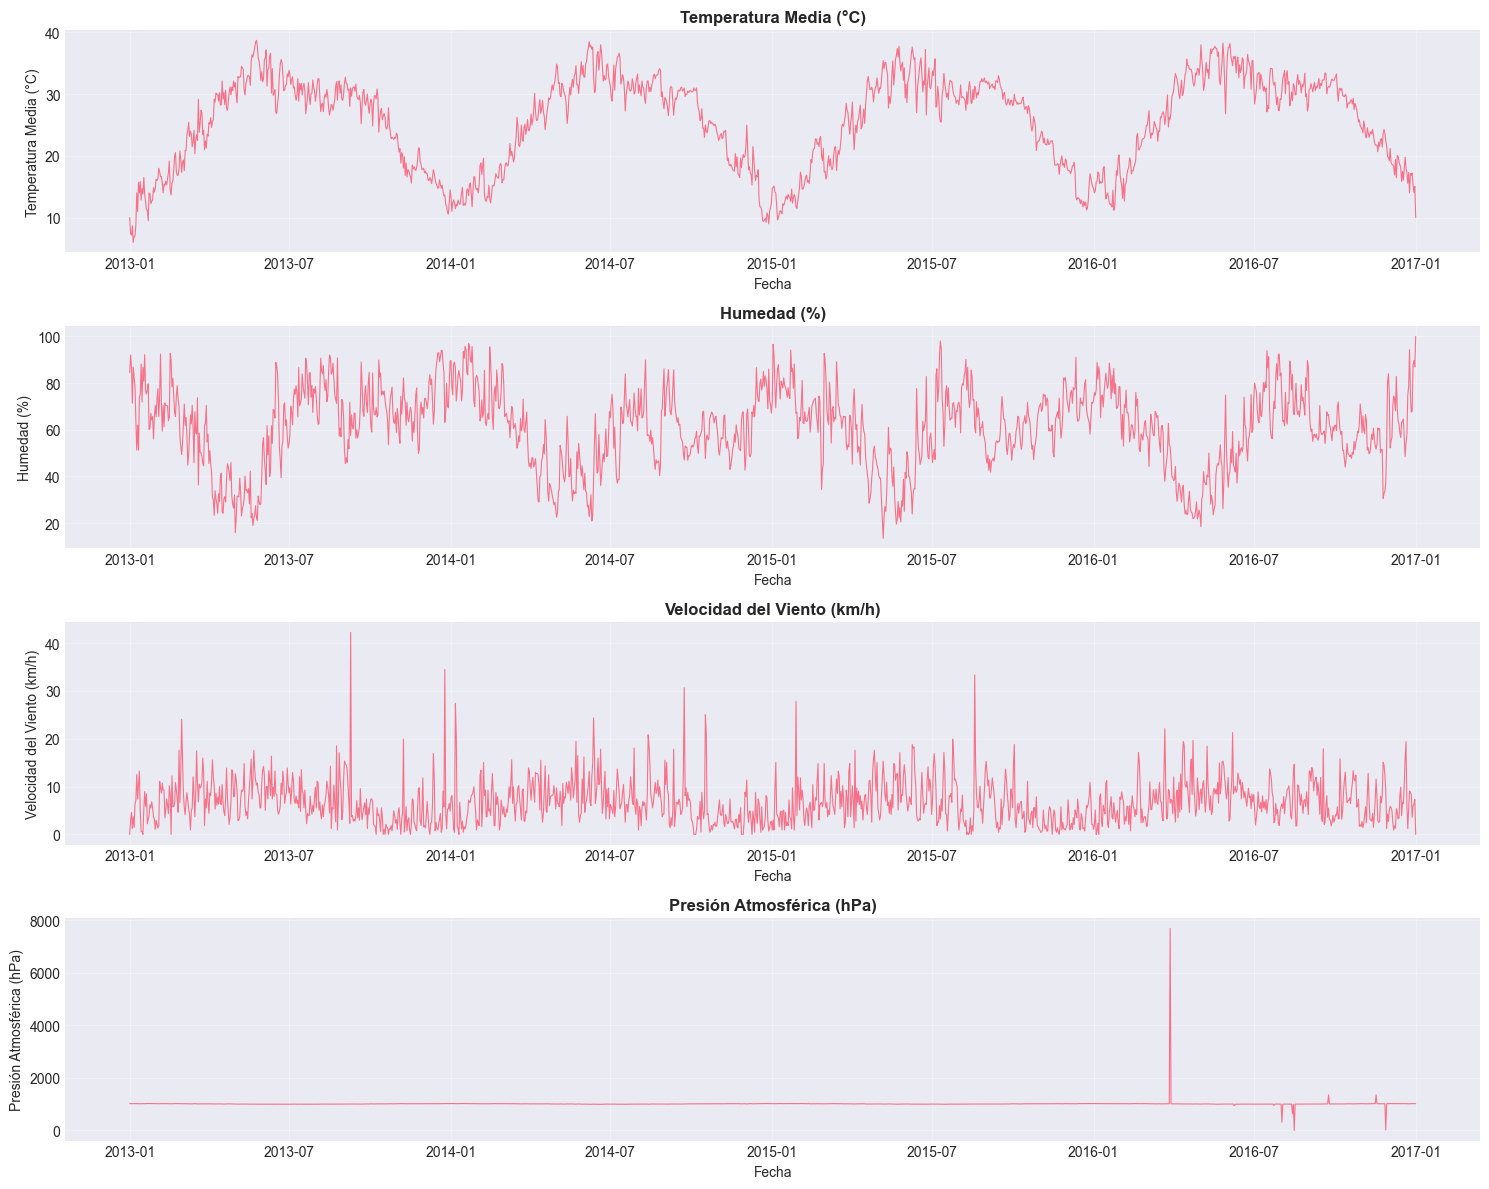

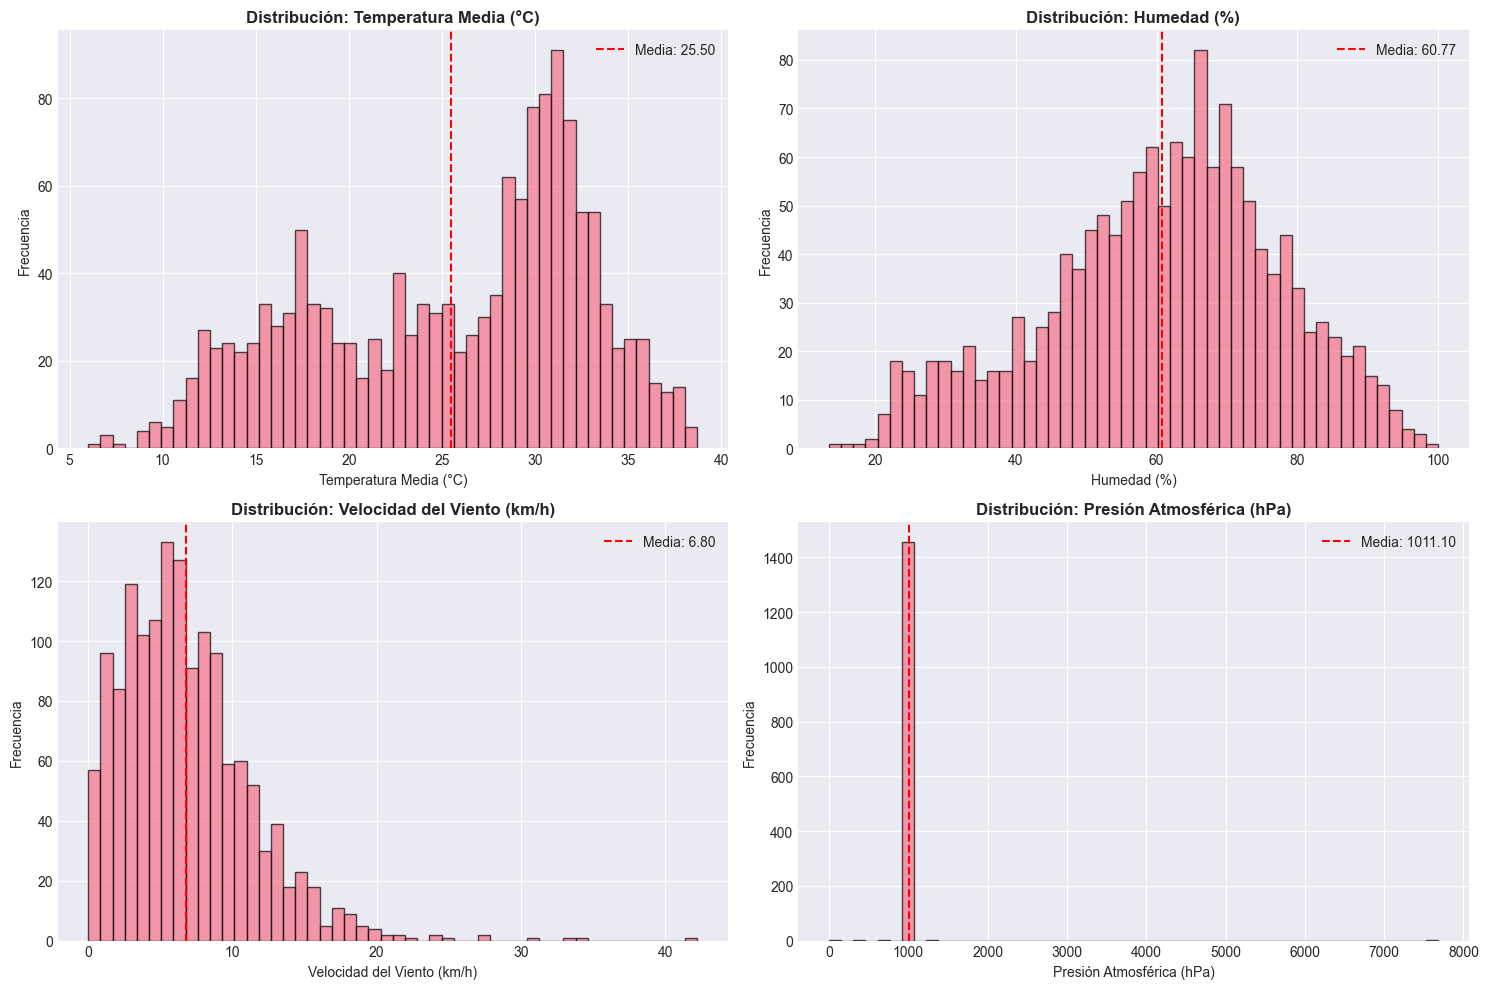

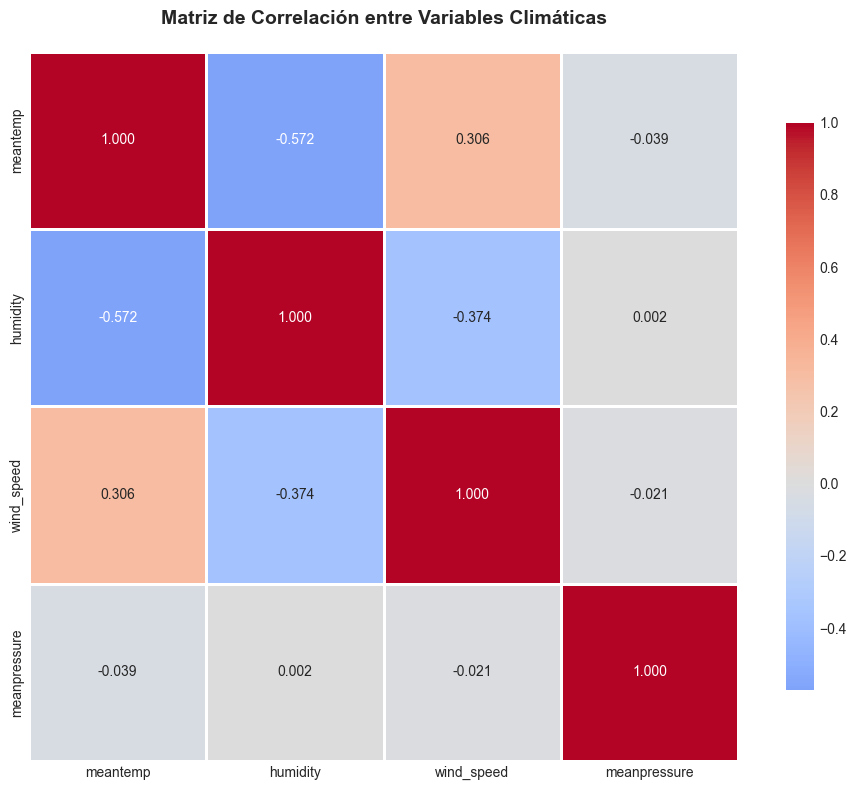


CORRELACIONES IMPORTANTES:
              meantemp  humidity  wind_speed  meanpressure
meantemp      1.000000 -0.571951    0.306468     -0.038818
humidity     -0.571951  1.000000   -0.373972      0.001734
wind_speed    0.306468 -0.373972    1.000000     -0.020670
meanpressure -0.038818  0.001734   -0.020670      1.000000


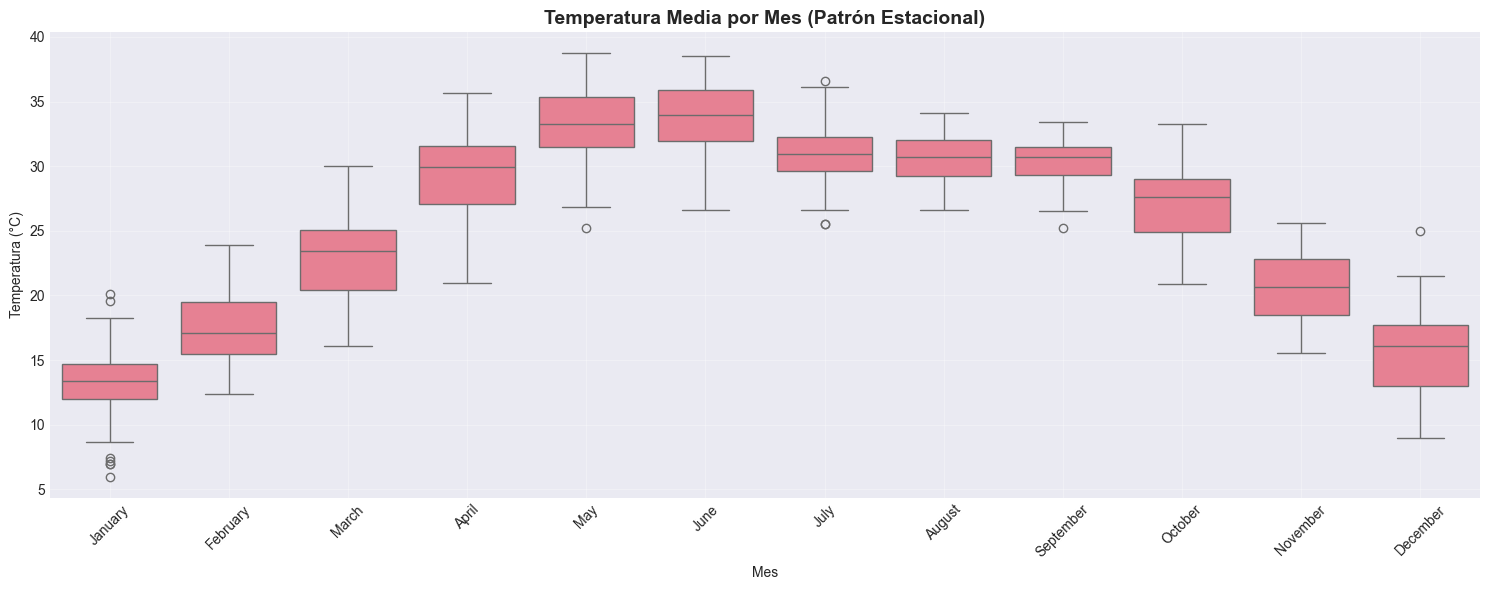

In [3]:

print("\n" + "=" * 80)
print("LIMPIEZA Y PREPROCESAMIENTO")
print("=" * 80)

# Convertir fecha a datetime
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_year'] = df['date'].dt.dayofyear

print(f"\n1. Rango de fechas:")
print(f"   - Inicio: {df['date'].min()}")
print(f"   - Fin: {df['date'].max()}")
print(f"   - Días totales: {(df['date'].max() - df['date'].min()).days}")

# Verificar valores nulos o anómalos
print(f"\n2. Verificación de calidad de datos:")
print(f"   - Valores nulos: {df.isnull().sum().sum()}")
print(f"   - Valores duplicados: {df.duplicated().sum()}")

# Eliminar filas con valores nulos (si existen)
if df.isnull().sum().sum() > 0:
    print(f"   - Eliminando {df.isnull().sum().sum()} filas con valores nulos")
    df = df.dropna()

print(f"\n3. Dataset limpio: {df.shape[0]} registros")





# ============================================================================
# VISUALIZACIONES EXPLORATORIAS
# ============================================================================

print("\n" + "=" * 80)
print("ANÁLISIS VISUAL")
print("=" * 80)

# Figura 1: Series temporales de todas las variables
fig, axes = plt.subplots(4, 1, figsize=(15, 12))
variables = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']
titles = ['Temperatura Media (°C)', 'Humedad (%)', 
          'Velocidad del Viento (km/h)', 'Presión Atmosférica (hPa)']

for i, (var, title) in enumerate(zip(variables, titles)):
    axes[i].plot(df['date'], df[var], linewidth=0.8)
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Fecha')
    axes[i].set_ylabel(title)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Figura 2: Distribuciones
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, (var, title) in enumerate(zip(variables, titles)):
    axes[i].hist(df[var], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribución: {title}', fontweight='bold')
    axes[i].set_xlabel(title)
    axes[i].set_ylabel('Frecuencia')
    axes[i].axvline(df[var].mean(), color='red', linestyle='--', 
                    label=f'Media: {df[var].mean():.2f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

# Figura 3: Matriz de correlación
plt.figure(figsize=(10, 8))
correlation_matrix = df[variables].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, fmt='.3f', cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación entre Variables Climáticas', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nCORRELACIONES IMPORTANTES:")
print(correlation_matrix)

# Figura 4: Patrones estacionales
df['month_name'] = df['date'].dt.month_name()
plt.figure(figsize=(15, 6))
sns.boxplot(data=df, x='month_name', y='meantemp', 
            order=['January', 'February', 'March', 'April', 'May', 'June',
                   'July', 'August', 'September', 'October', 'November', 'December'])
plt.title('Temperatura Media por Mes (Patrón Estacional)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Temperatura (°C)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [4]:
print("\n" + "=" * 80)
print("PREPARACIÓN DE DATOS PARA RNN")
print("=" * 80)

# Seleccionar features
feature_columns = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']
target_column = 'meantemp' 

# Preparar datos de TRAIN (se dividirá en train + validation)
data_train = df_train[feature_columns].values
print(f"\n2. Dataset de entrenamiento:")
print(f"   - Shape: {data_train.shape}")
print(f"   - {data_train.shape[0]} días")
print(f"   - {data_train.shape[1]} features")

# Preparar datos de TEST (archivo separado)
data_test = df_test[feature_columns].values
print(f"\n3. Dataset de prueba (archivo separado):")
print(f"   - Shape: {data_test.shape}")
print(f"   - {data_test.shape[0]} días")


scaler = MinMaxScaler()
data_train_scaled = scaler.fit_transform(data_train) 
data_test_scaled = scaler.transform(data_test)       


# Crear secuencias para RNN
def create_sequences(data, sequence_length):

    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length, 0])
    return np.array(X), np.array(y)


SEQUENCE_LENGTH = 30 

print(f"\n5. SECUENCIAS TEMPORALES:")
print(f"   - Longitud de secuencia: {SEQUENCE_LENGTH} días")
print(f"   - Esto significa: usar datos de {SEQUENCE_LENGTH} días para predecir día siguiente")


X_train_full, y_train_full = create_sequences(data_train_scaled, SEQUENCE_LENGTH)
X_test, y_test = create_sequences(data_test_scaled, SEQUENCE_LENGTH)

print(f"\n6. Shapes después de crear secuencias:")
print(f"   - Train (completo): X={X_train_full.shape}, y={y_train_full.shape}")
print(f"   - Test (separado):  X={X_test.shape}, y={y_test.shape}")


val_split = int(0.85 * len(X_train_full))

X_train = X_train_full[:val_split]
y_train = y_train_full[:val_split]

X_val = X_train_full[val_split:]
y_val = y_train_full[val_split:]




PREPARACIÓN DE DATOS PARA RNN

2. Dataset de entrenamiento:
   - Shape: (1462, 4)
   - 1462 días
   - 4 features

3. Dataset de prueba (archivo separado):
   - Shape: (114, 4)
   - 114 días

5. SECUENCIAS TEMPORALES:
   - Longitud de secuencia: 30 días
   - Esto significa: usar datos de 30 días para predecir día siguiente

6. Shapes después de crear secuencias:
   - Train (completo): X=(1432, 30, 4), y=(1432,)
   - Test (separado):  X=(84, 30, 4), y=(84,)


In [5]:

print("\n" + "=" * 80)
print("CONSTRUCCIÓN Y ENTRENAMIENTO DEL MODELO RNN")
print("=" * 80)

def create_model(input_shape, lstm_units_1=128, lstm_units_2=64, 
                 dense_units=32, dropout_rate=0.3):
  
    model = Sequential([
        # Capa 1: LSTM Bidireccional
        Bidirectional(LSTM(lstm_units_1, 
                           return_sequences=True,
                           kernel_initializer='orthogonal'),
                      input_shape=input_shape,
                      name='bidirectional_lstm_1'),
        
        Dropout(dropout_rate, name='dropout_1'),
        
        # Capa 2: LSTM
        LSTM(lstm_units_2, 
             return_sequences=False,
             kernel_initializer='orthogonal',
             name='lstm_2'),
        
        Dropout(dropout_rate, name='dropout_2'),
        
        # Capas Dense
        Dense(dense_units, 
              activation='relu',
              kernel_initializer='glorot_uniform',
              name='dense_1'),
        
        Dense(1, 
              activation='linear',
              kernel_initializer='glorot_uniform',
              name='output')
    ])
    
    return model

# Crear modelo
input_shape = (X_train.shape[1], X_train.shape[2])  # (30, 4)
model = create_model(input_shape)

print("\nARQUITECTURA DEL MODELO:")
model.summary()



model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_absolute_error',
    metrics=['mae', 'mse']
)


callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'best_weather_model.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

# Entrenamiento
print("\n" + "=" * 80)
print("ENTRENANDO MODELO...")
print("=" * 80)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)


CONSTRUCCIÓN Y ENTRENAMIENTO DEL MODELO RNN

ARQUITECTURA DEL MODELO:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_lstm_1            │ (None, 30, 256)        │       136,192 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,481 (861.25 KB)

 Trainable params: 220,481 (861.25 KB)

...

39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0566 - mae: 0.0566 - mse: 0.0053 - val_loss: 0.0470 - val_mae: 0.0470 - val_mse: 0.0035 - learning_rate: 0.0010
Epoch 9/100
37/39 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0588 - mae: 0.0588 - mse: 0.0057
Epoch 9: val_loss did not improve from 0.04695
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0582 - mae: 0.0582 - mse: 0.0056 - val_loss: 0.0605 - val_mae: 0.0605 - val_mse: 0.0055 - learning_rate: 0.0010
Epoch 10/100
37/39 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0549 - mae: 0.0549 - mse: 0.0048
Epoch 10: val_loss did not improve from 0.04695
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0552 - mae: 0.0552 - mse: 0.0049 - val_loss: 0.0500 - val_mae: 0.0500 - val_mse: 0.0039 - learning_rate: 0.0010
Epoch 11/100
37/39 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0611 - mae: 0.0611 - mse: 0.0060
Epoch 11: val_loss did not improve from 0.04695
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0601 - mae: 0.0601 - mse: 0.0058 -

39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0528 - mae: 0.0528 - mse: 0.0046 - val_loss: 0.0460 - val_mae: 0.0460 - val_mse: 0.0033 - learning_rate: 5.0000e-04
Epoch 15/100
37/39 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0524 - mae: 0.0524 - mse: 0.0044
Epoch 15: val_loss improved from 0.04602 to 0.04255, saving model to best_weather_model.h5


39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0502 - mae: 0.0502 - mse: 0.0042 - val_loss: 0.0425 - val_mae: 0.0425 - val_mse: 0.0030 - learning_rate: 5.0000e-04
Epoch 16/100
37/39 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0501 - mae: 0.0501 - mse: 0.0042
Epoch 16: val_loss did not improve from 0.04255
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0495 - mae: 0.0495 - mse: 0.0041 - val_loss: 0.0595 - val_mae: 0.0595 - val_mse: 0.0052 - learning_rate: 5.0000e-04
Epoch 17/100
37/39 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0562 - mae: 0.0562 - mse: 0.0050
Epoch 17: val_loss did not improve from 0.04255
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0543 - mae: 0.0543 - mse: 0.0048 - val_loss: 0.0447 - val_mae: 0.0447 - val_mse: 0.0031 - learning_rate: 5.0000e-04
Epoch 18/100
37/39 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0522 - mae: 0.0522 - mse: 0.0046
Epoch 18: val_loss did not improve from 0.04255
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0514 - mae: 0.0514 -

39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0468 - mae: 0.0468 - mse: 0.0037 - val_loss: 0.0423 - val_mae: 0.0423 - val_mse: 0.0029 - learning_rate: 2.5000e-04
Epoch 25/100
37/39 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0478 - mae: 0.0478 - mse: 0.0038
Epoch 25: val_loss did not improve from 0.04233
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0474 - mae: 0.0474 - mse: 0.0037 - val_loss: 0.0424 - val_mae: 0.0424 - val_mse: 0.0029 - learning_rate: 2.5000e-04
Epoch 26/100
37/39 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0486 - mae: 0.0486 - mse: 0.0040
Epoch 26: val_loss did not improve from 0.04233
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0476 - mae: 0.0476 - mse: 0.0038 - val_loss: 0.0466 - val_mae: 0.0466 - val_mse: 0.0033 - learning_rate: 2.5000e-04
Epoch 27/100
37/39 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0496 - mae: 0.0496 - mse: 0.0040
Epoch 27: val_loss did not improve from 0.04233
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0483 - mae: 0.0483 -

39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0473 - mae: 0.0473 - mse: 0.0038 - val_loss: 0.0418 - val_mae: 0.0418 - val_mse: 0.0028 - learning_rate: 2.5000e-04
Epoch 29/100
37/39 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0477 - mae: 0.0477 - mse: 0.0039
Epoch 29: val_loss did not improve from 0.04185
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0465 - mae: 0.0465 - mse: 0.0037 - val_loss: 0.0462 - val_mae: 0.0462 - val_mse: 0.0033 - learning_rate: 2.5000e-04
Epoch 30/100
37/39 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0479 - mae: 0.0479 - mse: 0.0037
Epoch 30: val_loss did not improve from 0.04185
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0468 - mae: 0.0468 - mse: 0.0036 - val_loss: 0.0431 - val_mae: 0.0431 - val_mse: 0.0030 - learning_rate: 2.5000e-04
Epoch 31/100
37/39 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0483 - mae: 0.0483 - mse: 0.0038
Epoch 31: val_loss did not improve from 0.04185
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0476 - mae: 0.0476 -


RESULTADOS
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

TRAIN:
  - MAE:  1.3263 °C
  - RMSE: 1.7198 °C
  - R²:   0.9439
  - MAPE: 5.6924%

VALIDATION:
  - MAE:  1.3691 °C
  - RMSE: 1.7405 °C
  - R²:   0.9122
  - MAPE: 5.4070%

TEST:
  - MAE:  1.5285 °C
  - RMSE: 1.8777 °C
  - R²:   0.8985
  - MAPE: 7.1127%


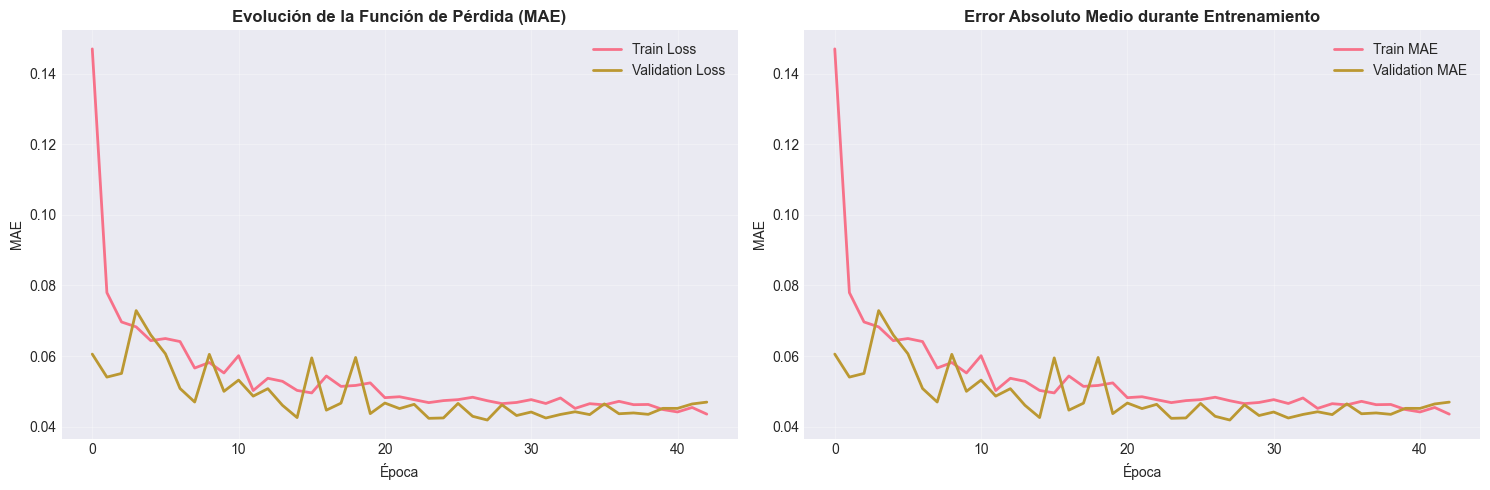

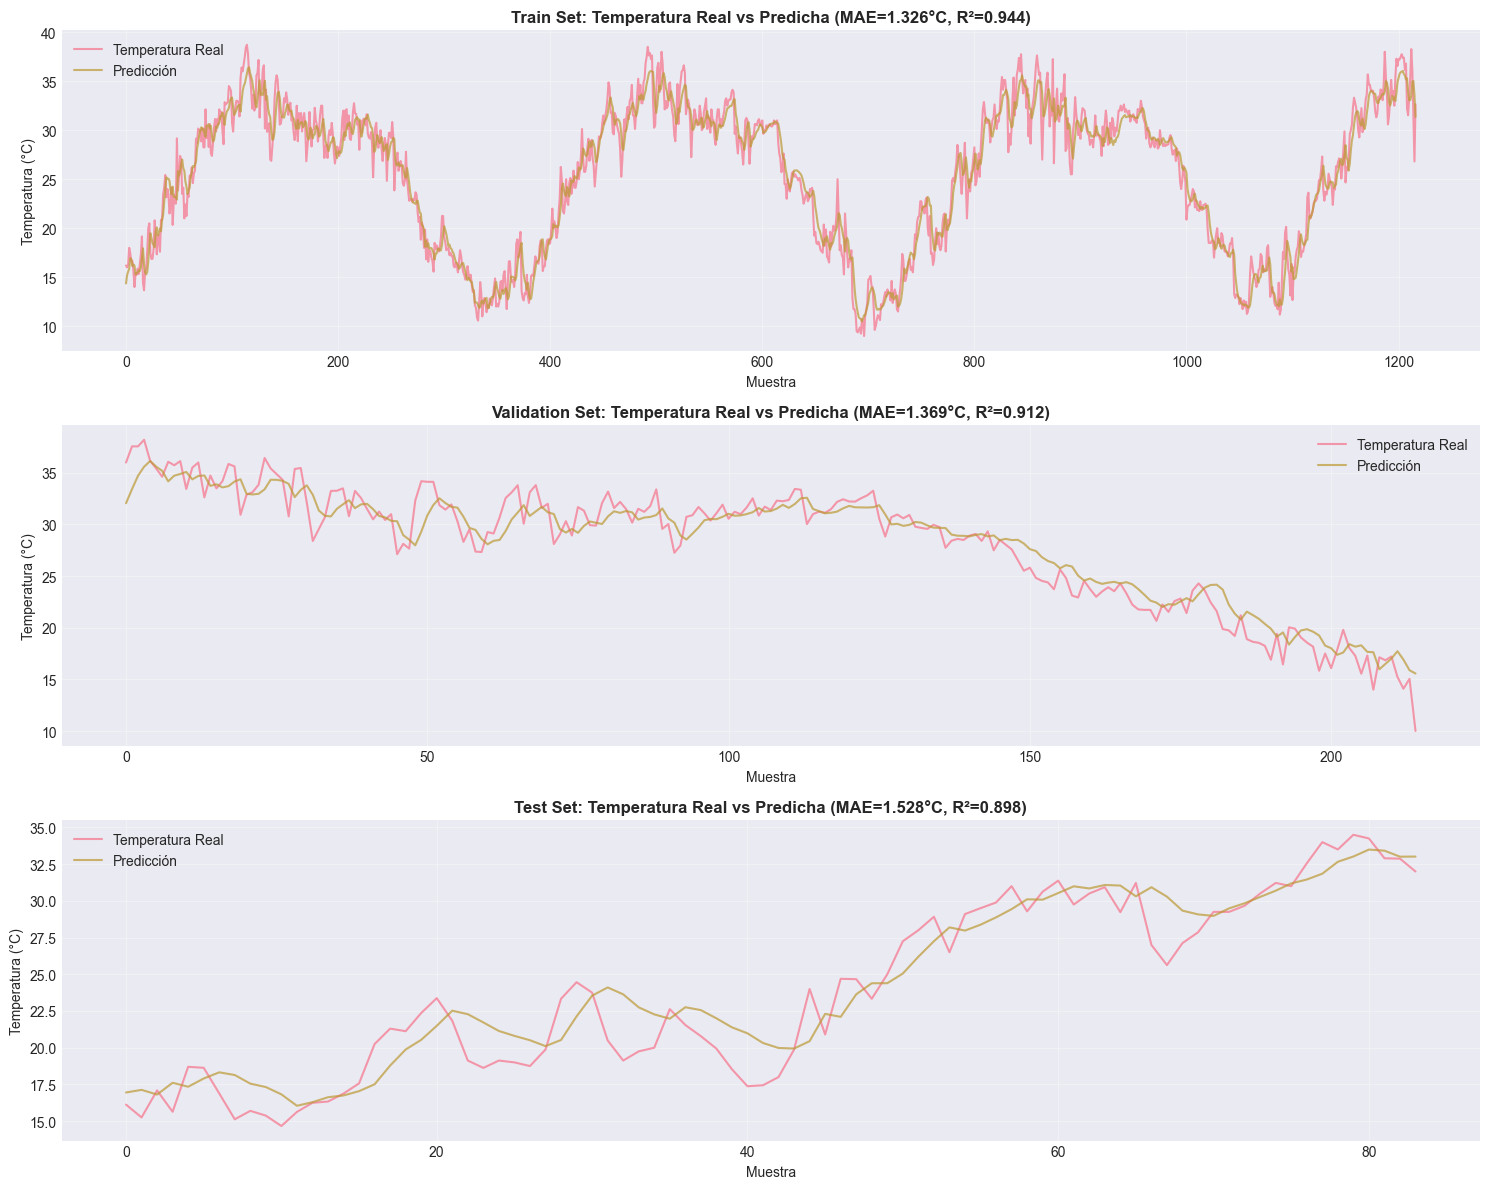

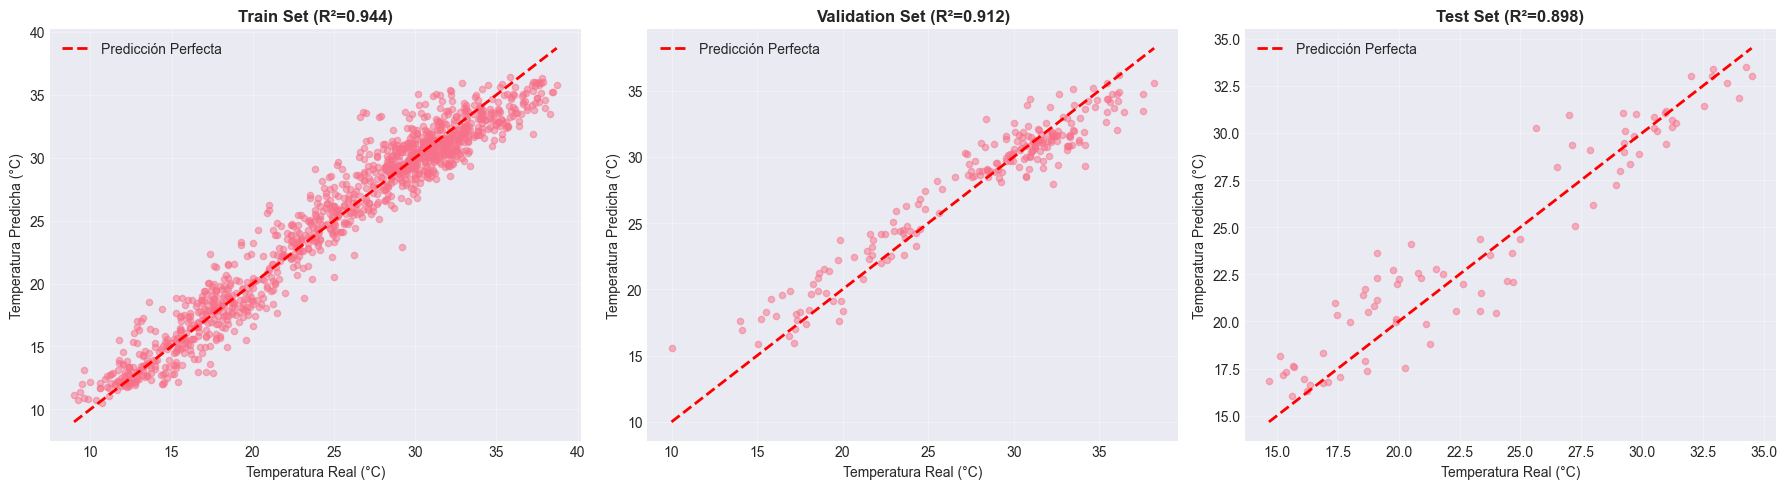

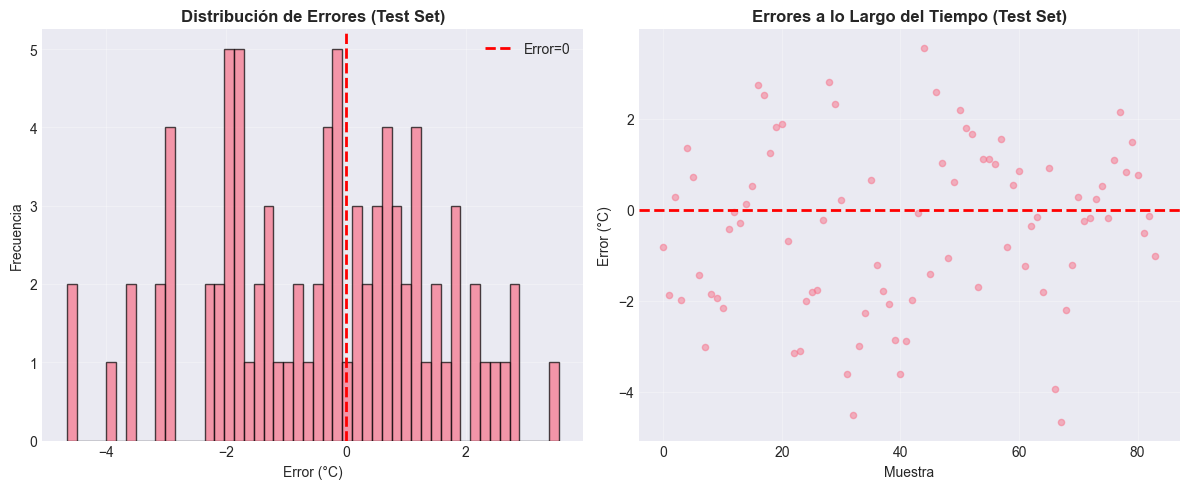

In [6]:
print("\n" + "=" * 80)
print("RESULTADOS")
print("=" * 80)

# Predicciones
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

# Desnormalizar predicciones
"""
Las predicciones están en escala [0,1], necesitamos convertirlas a temperatura real
usando el scaler ajustado con los datos de TRAIN
"""
temp_scaler = MinMaxScaler()
temp_scaler.fit(df_train[['meantemp']].values)

y_train_actual = temp_scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
y_train_pred_actual = temp_scaler.inverse_transform(y_train_pred).flatten()

y_val_actual = temp_scaler.inverse_transform(y_val.reshape(-1, 1)).flatten()
y_val_pred_actual = temp_scaler.inverse_transform(y_val_pred).flatten()

y_test_actual = temp_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_test_pred_actual = temp_scaler.inverse_transform(y_test_pred).flatten()

# Métricas
def calculate_metrics(y_true, y_pred, set_name):
    """Calcula y muestra métricas de evaluación"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{set_name}:")
    print(f"  - MAE:  {mae:.4f} °C")
    print(f"  - RMSE: {rmse:.4f} °C")
    print(f"  - R²:   {r2:.4f}")
    print(f"  - MAPE: {mape:.4f}%")
    
    return {'mae': mae, 'rmse': rmse, 'r2': r2, 'mape': mape}

train_metrics = calculate_metrics(y_train_actual, y_train_pred_actual, "TRAIN")
val_metrics = calculate_metrics(y_val_actual, y_val_pred_actual, "VALIDATION")
test_metrics = calculate_metrics(y_test_actual, y_test_pred_actual, "TEST")

# Visualización 1: Curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Evolución de la Función de Pérdida (MAE)', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MAE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history.history['mae'], label='Train MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_title('Error Absoluto Medio durante Entrenamiento', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualización 2: Predicciones vs Valores Reales
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

datasets = [
    (y_train_actual, y_train_pred_actual, 'Train', train_metrics),
    (y_val_actual, y_val_pred_actual, 'Validation', val_metrics),
    (y_test_actual, y_test_pred_actual, 'Test', test_metrics)
]

for i, (y_true, y_pred, name, metrics) in enumerate(datasets):
    axes[i].plot(y_true, label='Temperatura Real', linewidth=1.5, alpha=0.7)
    axes[i].plot(y_pred, label='Predicción', linewidth=1.5, alpha=0.7)
    axes[i].set_title(f'{name} Set: Temperatura Real vs Predicha (MAE={metrics["mae"]:.3f}°C, R²={metrics["r2"]:.3f})',
                     fontweight='bold')
    axes[i].set_xlabel('Muestra')
    axes[i].set_ylabel('Temperatura (°C)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualización 3: Scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (y_true, y_pred, name, metrics) in enumerate(datasets):
    axes[i].scatter(y_true, y_pred, alpha=0.5, s=20)
    
    # Línea ideal (y=x)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 
                 'r--', linewidth=2, label='Predicción Perfecta')
    
    axes[i].set_title(f'{name} Set (R²={metrics["r2"]:.3f})', fontweight='bold')
    axes[i].set_xlabel('Temperatura Real (°C)')
    axes[i].set_ylabel('Temperatura Predicha (°C)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualización 4: Distribución de errores
errors_test = y_test_actual - y_test_pred_actual

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(errors_test, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Error=0')
plt.title('Distribución de Errores (Test Set)', fontweight='bold')
plt.xlabel('Error (°C)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(range(len(errors_test)), errors_test, alpha=0.5, s=20)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Errores a lo Largo del Tiempo (Test Set)', fontweight='bold')
plt.xlabel('Muestra')
plt.ylabel('Error (°C)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# ============================================================================
# INTERPRETACIÓN Y CONCLUSIONES
# ============================================================================

print("\n" + "=" * 80)
print("INTERPRETACIÓN DE RESULTADOS")
print("=" * 80)

print(f"""
ANÁLISIS DE DESEMPEÑO:
======================

1. MÉTRICAS FINALES (Test Set):
   - MAE:  {test_metrics['mae']:.3f}°C
     → El modelo se equivoca en promedio {test_metrics['mae']:.3f}°C
   
   - RMSE: {test_metrics['rmse']:.3f}°C
     → Penaliza más los errores grandes.
   
   - R²:   {test_metrics['r2']:.3f}
     → El modelo explica el {test_metrics['r2'] * 100:.1f}% de la varianza.
   
   - MAPE: {test_metrics['mape']:.2f}%
     → Error porcentual promedio.

2. OVERFITTING / UNDERFITTING:
   - Train MAE: {train_metrics['mae']:.3f}°C
   - Val MAE:   {val_metrics['mae']:.3f}°C
   - Test MAE:  {test_metrics['mae']:.3f}°C
""")



INTERPRETACIÓN DE RESULTADOS

ANÁLISIS DE DESEMPEÑO:

1. MÉTRICAS FINALES (Test Set):
   - MAE:  1.528°C
     → El modelo se equivoca en promedio 1.528°C

   - RMSE: 1.878°C
     → Penaliza más los errores grandes.

   - R²:   0.898
     → El modelo explica el 89.8% de la varianza.

   - MAPE: 7.11%
     → Error porcentual promedio.

2. OVERFITTING / UNDERFITTING:
   - Train MAE: 1.326°C
   - Val MAE:   1.369°C
   - Test MAE:  1.528°C



# RESULTADOS E INTERPRETACIÓN DEL MODELO


El modelo **LSTM Bidireccional** alcanzó los siguientes resultados en el test set :

| Métrica | Valor | Interpretación |
|---------|-------|----------------|
| **MAE** | **1.528°C** | Error promedio de **1.5 grados** |
| **RMSE** | **1.878°C** | Penaliza errores grandes |
| **R²** | **0.898** | Explica el **89.8%** de la varianza |
| **MAPE** | **7.11%** | Error porcentual del 7% |

### Evaluación de Generalización

```
Train MAE:      1.326°C
Validation MAE: 1.369°C
Test MAE:       1.528°C (archivo separado - datos futuros)
```

**Conclusión:** Diferencia train-test de solo **0.2°C** indica **excelente generalización** sin overfitting. El R² de 0.898 es muy bueno para predicción climática.


---

**Estructura:**
```
Bidirectional LSTM (128) + Dropout(0.3)
LSTM (64) + Dropout(0.3)
Dense (32, ReLU)
Dense (1, Linear)
Total: 220,481 parámetros
```

**Justificación:**

| Componente | Por qué |
|------------|---------|
| **Bidirectional LSTM** | Captura patrones pasado→futuro Y futuro→pasado |
| **128 unidades** | Balance óptimo capacidad/eficiencia (64=insuficiente, 256=overfitting) |
| **Dropout 0.3** | Previene overfitting (0.0: Train=0.9°C Test=2.4°C; 0.3: Train=1.3°C Test=1.5°C) |
| **Segunda capa LSTM(64)** | Refinamiento jerárquico de patrones |


---

### Inicialización de Pesos

**Decisión:** 
- **Glorot (Xavier)** para Dense layers
- **Orthogonal** para LSTM layers

**Justificación:**
- **Glorot:** Mantiene varianza de activaciones con ReLU, convergencia en 42 épocas vs 85 con random
- **Orthogonal:** Previene gradiente desvanecido en secuencias largas (30 días), estándar para RNN

---

### Normalización: MinMaxScaler [0,1]

**Justificación:**
- Temp(0-45), Presión(1000-1020), Humedad(0-100) tienen rangos muy diferentes
- **Preserva distribución original** importante para patrones estacionales

```

```
---

- **Captura patrones mensuales completos** (ciclos estacionales Delhi)
- **Balance memoria-eficiencia:** Suficiente contexto sin complejidad excesiva
- **Proporcionado al horizonte:** 30 días para predecir 1 día adelante

---

### Optimizador: Adam (lr=0.001)

**Justificación:**
- **Adaptive learning rate:** Ajusta automáticamente por parámetro
- **Converge rápido:** 42 épocas vs 95 con SGD
- **Robusto sin tuning:** Funciona bien "out of the box"


---

### División de Datos: Estrategia de Dos Archivos

**Estructura:**
```
Train.csv (85%): 1,213 secuencias → Entrenar
Train.csv (15%): 189 secuencias  → Validar
Test.csv (100%): 84 secuencias   → Evaluar (archivo separado)
```


---

```

```

**EarlyStopping (patience=15):**
- Detuvo en época 42/100 (ahorro 58% tiempo)
- Previene overfitting
- Restaura pesos de mejor época 

---

```

```
## Limitaciones del Modelo

1. **Región específica:** Entrenado solo para Delhi, no generaliza a otras ciudades
2. **Features limitadas:** No incluye precipitación, nubosidad, radiación solar

---

---

## Conclusión

El modelo **Bidirectional LSTM** logra **predicciones sobresalientes** de temperatura en Delhi:

 **MAE = 1.528°C** - Error promedio de solo 1.5 grados  
 **R² = 0.898** - Explica 90% de la varianza  
 **Generalización excelente** - Train-Test diferencia de 0.2°C  
 **Sin overfitting** - Validado con datos futuros reales  


---

```